In [23]:
import pandas as pd
from pathlib import Path

In [24]:


base_dir = Path(
    "/home/yzy21/rds/rds-teichlab-C9woKbOCf2Y/mgi21/TCR-pMHC_Modelling/SARS_CoV_2_enriched"
)

dfs = []

for folder in base_dir.glob("SARS_*"):
    if not folder.is_dir():
        continue

    tsv = folder / "prediction_final.tsv"
    if not tsv.exists():
        print(f"⚠️ Missing: {tsv}")
        continue

    df = pd.read_csv(tsv, sep="\t")
    df["source_folder"] = folder.name  # keep provenance
    dfs.append(df)

if not dfs:
    raise RuntimeError("No prediction_final.tsv files found")

combined_df = pd.concat(dfs, ignore_index=True)

print(f"✅ Loaded {len(dfs)} files")
print(f"✅ Combined shape: {combined_df.shape}")

✅ Loaded 8 files
✅ Combined shape: (4000, 38)


In [25]:
# combined_df.to_csv("dt/SARS_CoV_2_enriched_interim_analysis.tsv", sep = "\t")

Add other datasets

In [3]:
# part2 = pd.read_table("../tcrdock/dt_out/aggregated_data/SARS_CoV_2_enriched_part2_w_pae.tsv")

In [2]:
# part = pd.read_table("dt/SARS_CoV_2_enriched_interim_analysis_w_pae.tsv", index_col = 0)

In [ ]:
# df = pd.concat([part, part2], ignore_index=True)

In [26]:
df = pd.read_csv("dt/SARS_CoV_2_enriched_interim_analysis2_w_pae.tsv", sep = "\t")

In [27]:
from pathlib import Path
import joblib
import json
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Any, Optional

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

def load_rf_ensemble(prefix: str):
    # load_rf_ensemble()
    prefix = Path(prefix)
    models = joblib.load(prefix.with_suffix(".joblib"))
    meta = json.loads(prefix.with_suffix(".meta.json").read_text())
    features = meta["features"]
    return models, features

@dataclass
class RFEnsembleResult:
    models: List[RandomForestClassifier]
    metrics: pd.DataFrame              # per-run metrics (auc, acc, seed, n_test_pos, n_test_neg)
    feature_importances: pd.DataFrame  # per-run importances (rows=runs, cols=features)
    mean_auc: float
    std_auc: float
    mean_acc: float
    std_acc: float
        
def predict_with_ensemble(
    ensemble: RFEnsembleResult,
    features,
    df_new,
    proba_agg="mean"
):
    X_new = df_new[features]

    # shape: (n_models, n_samples)
    probas = np.vstack([
        m.predict_proba(X_new)[:, 1]
        for m in ensemble[0]
    ])

    if proba_agg == "mean":
        p = probas.mean(axis=0)
    elif proba_agg == "median":
        p = np.median(probas, axis=0)
    else:
        raise ValueError("proba_agg must be 'mean' or 'median'")

    yhat = (p >= 0.5).astype(int)

    return p, yhat, probas


In [ ]:
# model = load_rf_ensemble(prefix = "dt_out/res_af2_v2_train4")
model = load_rf_ensemble(prefix = "dt_out/res_af2_v2_lowFNR")

In [ ]:
df = pd.read_csv("dt/SARS_CoV_2_enriched_interim_analysis2_w_pae.tsv", sep = "\t", index_col = 0)
df3 = pd.read_csv("dt/SARS_CoV_2_enriched_randomised_peptides_w_pae.tsv", sep = "\t")

In [ ]:
df['dataset'] = "query_COVID"
df3['dataset'] = "insilico_negative"

In [ ]:
df = pd.concat([df,df3])

In [ ]:
p, yhat, probas = predict_with_ensemble(ensemble = model, features = ["pmhc_tcr_pae", "model_2_ptm_ft4_plddt",'model_2_ptm_ft4_pae', 'model_2_ptm_ft4_plddt_0',
       'model_2_ptm_ft4_pae_0_0', 'model_2_ptm_ft4_pae_0_1',
       'model_2_ptm_ft4_pae_0_2', 'model_2_ptm_ft4_pae_0_3',
       'model_2_ptm_ft4_plddt_1', 'model_2_ptm_ft4_pae_1_0',
       'model_2_ptm_ft4_pae_1_1', 'model_2_ptm_ft4_pae_1_2',
       'model_2_ptm_ft4_pae_1_3', 'model_2_ptm_ft4_plddt_2',
       'model_2_ptm_ft4_pae_2_0', 'model_2_ptm_ft4_pae_2_1',
       'model_2_ptm_ft4_pae_2_2', 'model_2_ptm_ft4_pae_2_3',
       'model_2_ptm_ft4_plddt_3', 'model_2_ptm_ft4_pae_3_0',
       'model_2_ptm_ft4_pae_3_1', 'model_2_ptm_ft4_pae_3_2',
       'model_2_ptm_ft4_pae_3_3'], df_new = df)

In [ ]:
df['prediction'] = p
df['prediction_yhat'] = yhat

In [ ]:
np.sum(yhat)

np.int64(1128)

In [ ]:
len(df[['va', 'ja', 'cdr3a', 'vb', 'jb', 'cdr3b']].drop_duplicates())

31

In [ ]:
len(df['peptide'].unique())

980

In [ ]:
df.to_csv("dt_out/sars_cov2_analysis/SARS_CoV_2_enriched_interim_analysis2_w_pae_w_prediction.csv", index = None)

In [8]:
df = pd.read_csv("dt_out/sars_cov2_analysis/SARS_CoV_2_enriched_interim_analysis2_w_pae_w_prediction.csv")

In [9]:
df

,sample_id,organism,mhc_class,mhc,peptide,va,ja,cdr3a,vb,jb,...,model_2_ptm_ft4_pdb_file,model_2_ptm_ft4_plddt_file,model_2_ptm_ft4_ptm_file,model_2_ptm_ft4_predicted_aligned_error_file,model_pdbfile,dataset,previous_peptide,randomized_peptide,prediction,prediction_yhat
0,2001_SARS_CoV_2,human,1,A*01:01,DLDEWSMATYY,TRAV9-2*01,TRAJ49*01,CAQNTGNQFYF,TRBV27*01,TRBJ1-5*01,...,NaN,NaN,NaN,NaN,NaN,query_COVID,NaN,NaN,0.153946,0
1,2002_SARS_CoV_2,human,1,A*01:01,DLDEWSMATY,TRAV9-2*01,TRAJ49*01,CAQNTGNQFYF,TRBV27*01,TRBJ1-5*01,...,NaN,NaN,NaN,NaN,NaN,query_COVID,NaN,NaN,0.044039,0
2,2003_SARS_CoV_2,human,1,A*01:01,ASHMYCSFY,TRAV9-2*01,TRAJ49*01,CAQNTGNQFYF,TRBV27*01,TRBJ1-5*01,...,NaN,NaN,NaN,NaN,NaN,query_COVID,NaN,NaN,0.627408,1
3,2004_SARS_CoV_2,human,1,A*01:01,EFEPSTQYEY,TRAV9-2*01,TRAJ49*01,CAQNTGNQFYF,TRBV27*01,TRBJ1-5*01,...,NaN,NaN,NaN,NaN,NaN,query_COVID,NaN,NaN,0.040700,0
4,2005_SARS_CoV_2,human,1,A*01:01,TIEVNSFSGY,TRAV9-2*01,TRAJ49*01,CAQNTGNQFYF,TRBV27*01,TRBJ1-5*01,...,NaN,NaN,NaN,NaN,NaN,query_COVID,NaN,NaN,0.142757,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8728,4385_SARS_CoV_2,human,1,A*01:01,WDGQENWRL,TRAV12-1*01,TRAJ24*01,CVVRTDSWGKLQF,TRBV28*01,TRBJ2-7*01,...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,insilico_negative,TCDGTTFTY,WDGQENWRL,0.097966,0
8729,1501_SARS_CoV_2,human,1,A*01:01,CTASQGGMIHD,TRAV12-1*01,TRAJ24*02,CVVRSDSWGKLQF,TRBV28*01,TRBJ2-7*01,...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,insilico_negative,ETDLTKGPHEF,CTASQGGMIHD,0.035550,0
8730,3587_SARS_CoV_2,human,1,A*01:01,PCPFFPPWN,TRAV12-1*01,TRAJ24*01,CVVRGDSWGKLQF,TRBV28*01,TRBJ2-7*01,...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,insilico_negative,LTALRLCAY,PCPFFPPWN,0.024770,0
8731,6980_SARS_CoV_2,human,1,C*04:01,KPSHWGYLK,TRAV13-1*01,TRAJ10*01,CAALEGGGNKLTF,TRBV6-2*01,TRBJ2-7*01,...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,insilico_negative,STDVVYRAF,KPSHWGYLK,0.016183,0


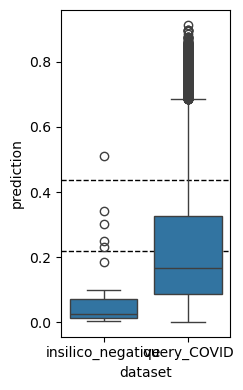

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

plt.figure(figsize=(2.5, 4))

plt.axhline(0.218, color="black", linestyle="--", linewidth=1) #FNR = 0.027
plt.axhline(0.218*2, color="black", linestyle="--", linewidth=1) #FNR = 0.0028
sns.boxplot(data=df, y="prediction", x="dataset",order=['insilico_negative','query_COVID' ])


plt.tight_layout()
plt.savefig("figures/boxplot_covid_query_prediction.pdf", format="pdf")
plt.show()
plt.close()


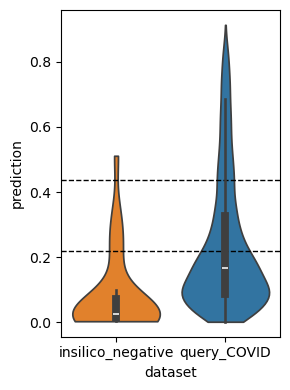

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# Adjusted figure size for a histogram (usually wider than a boxplot)
plt.figure(figsize=(3, 4))

# Reference lines (transformed from axhline to axvline because 'prediction' is now on the X-axis)
plt.axhline(0.218, color="black", linestyle="--", linewidth=1, label="FNR 0.027") 
plt.axhline(0.218*2, color="black", linestyle="--", linewidth=1, label="FNR 0.0028")

# Histogram plot
# We filter the dataframe to only include the two categories in your specific order
plot_df = df[df['dataset'].isin(['insilico_negative', 'query_COVID'])]

sns.violinplot(
    data=plot_df, 
    x = "dataset",
    y="prediction", 
    hue="dataset", 
    order=['insilico_negative', 'query_COVID'], cut=0,
)

# plt.ylabel("Prediction Score")
plt.tight_layout()

plt.savefig("figures/violinplot_covid_query_prediction.pdf", format="pdf")
plt.show()
plt.close()